Results Comparison:
Baseline - MAE: 6.3474, RMSE: 6.4943, R2: -1.4317
Improved - MAE: 3.7133, RMSE: 4.1714, R2: -0.0033


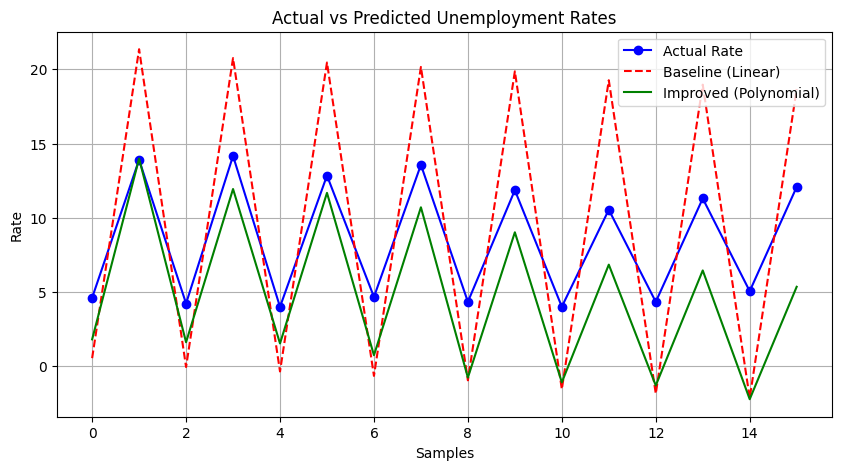

Model saved as improved_polynomial_model.pkl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load the cleaned dataset
df = pd.read_csv('cleaned_unemployment_data.csv')

# Define features and target variable
X = df[['Year', 'Quarter_Number', 'Gender']]
y = df['Unemployment_Rate']

# Convert categorical features to dummy variables if needed
if X['Gender'].dtype == 'object':
    X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Chronological split without shuffling to preserve time series order
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train the baseline model to verify current results
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# Calculate baseline metrics
base_mae = mean_absolute_error(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_r2 = r2_score(y_test, y_pred_base)

# Train the improved model using Polynomial Regression
poly_features = PolynomialFeatures(degree=2)
improved_model = make_pipeline(poly_features, LinearRegression())
improved_model.fit(X_train, y_train)
y_pred_poly = improved_model.predict(X_test)

# Calculate improved model metrics
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_r2 = r2_score(y_test, y_pred_poly)

# Print comparison results
print("Results Comparison:")
print(f"Baseline - MAE: {base_mae:.4f}, RMSE: {base_rmse:.4f}, R2: {base_r2:.4f}")
print(f"Improved - MAE: {poly_mae:.4f}, RMSE: {poly_rmse:.4f}, R2: {poly_r2:.4f}")

# Plot actual values vs both models for visual comparison
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual Rate", color='blue', marker='o')
plt.plot(y_pred_base, label="Baseline (Linear)", color='red', linestyle='--')
plt.plot(y_pred_poly, label="Improved (Polynomial)", color='green', linestyle='-')
plt.title("Actual vs Predicted Unemployment Rates")
plt.xlabel("Samples")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()

# Save the updated model artifact
joblib.dump(improved_model, 'improved_polynomial_model.pkl')
print("Model saved as improved_polynomial_model.pkl")
